# Análisis Multivariable de los datos
Por Mateo Soto

Última actualización: 20/Ago/2026

## Description
Estudio de relaciones entre 3+ variables simultáneamente, cuantificación formal de
multicolinealidad, y cierre del modelo heurístico baseline con las variables validadas
en los análisis univariable y bivariable.


## 📚 Import  libraries

In [6]:
# base libraries for data science
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

pd.set_option("display.float_format", "{:.2f}".format)
print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.13 (main, Jul 23 2026, 14:43:28) [Clang 22.1.3 ]
Pandas version:  3.0.5


## 💾 Load data

In [3]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
boston_df = pd.read_parquet(
    DATA_DIR / "02_intermediate/boston_type_fixed.parquet", engine="pyarrow"
)


Pairplot — variables más relevantes según el bivariable

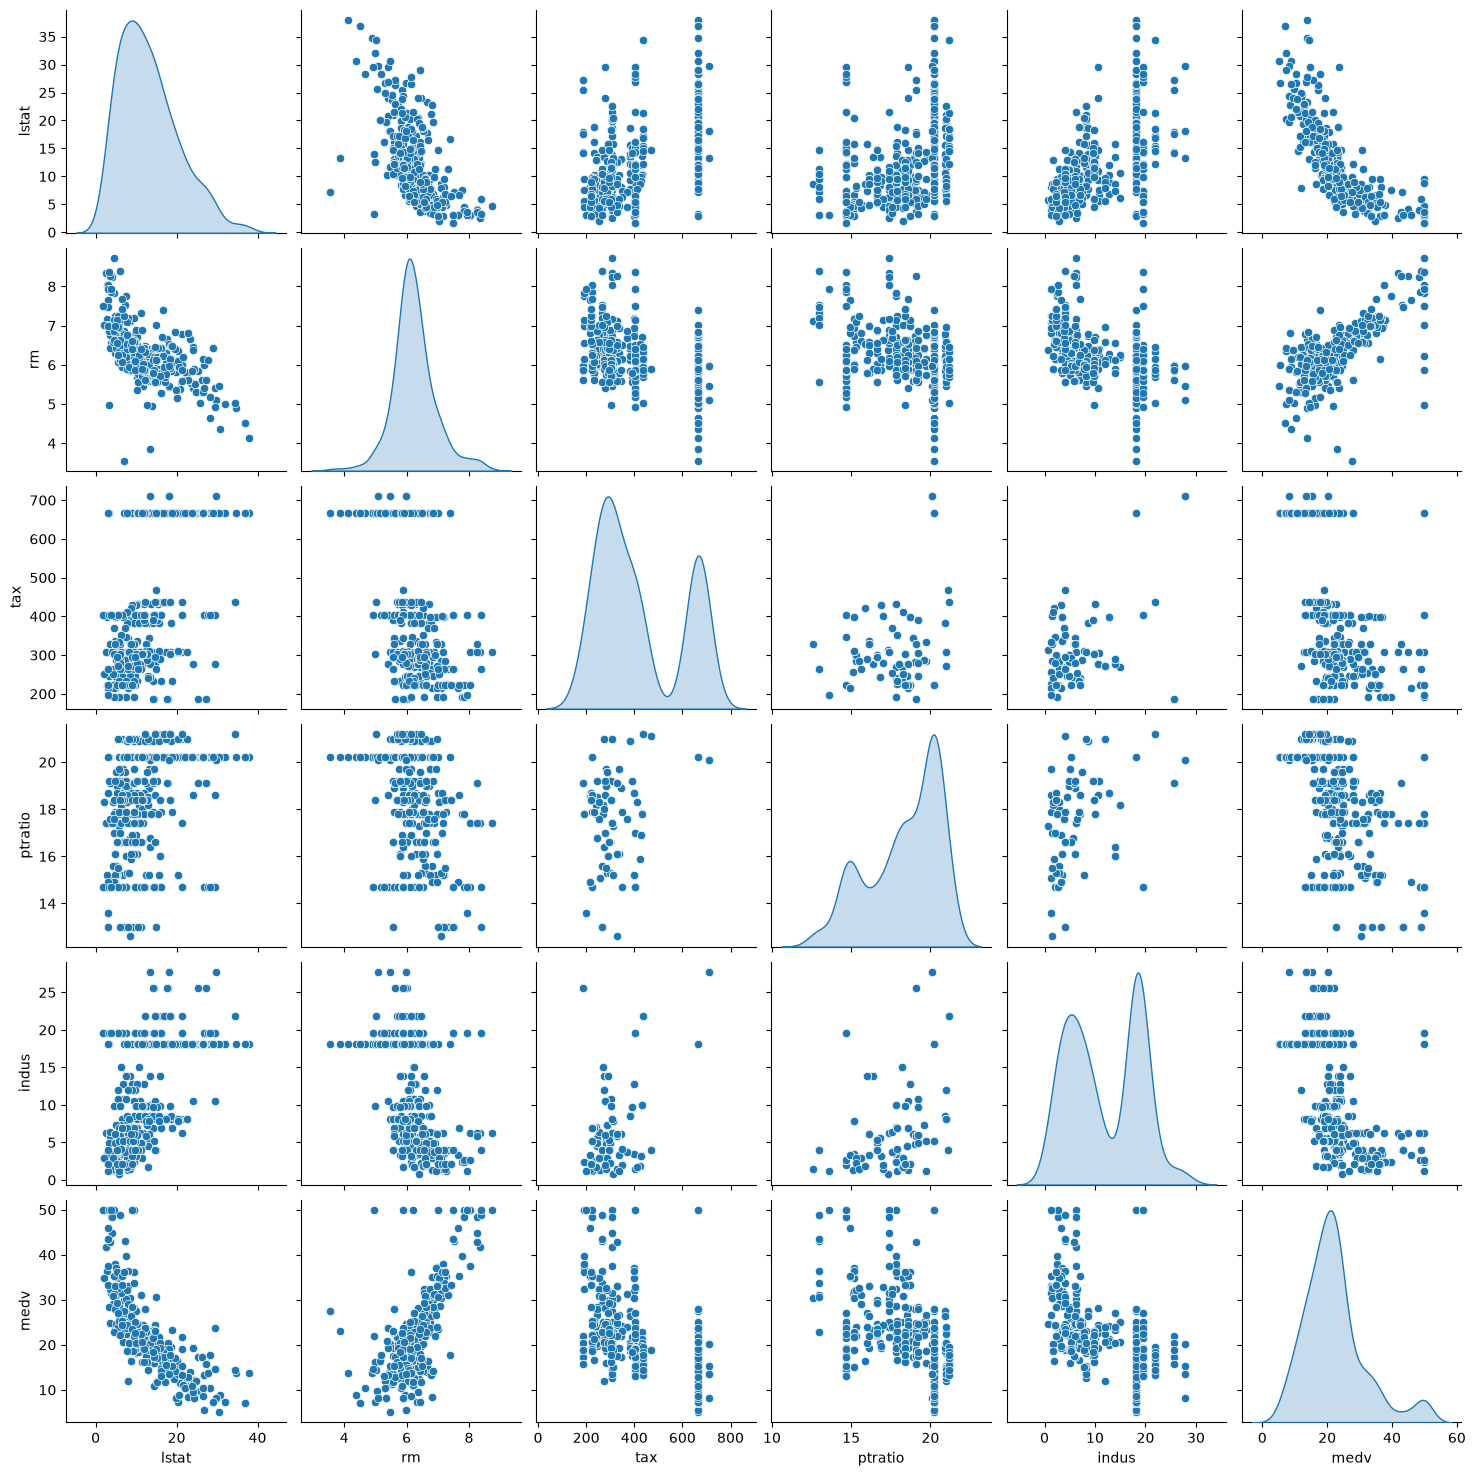

In [4]:
top_vars = ["lstat", "rm", "tax", "ptratio", "indus", "medv"]
sns.pairplot(boston_df[top_vars].dropna(), diag_kind="kde")


Multicolinealidad formal — VIF

In [7]:
predictors = [
    "crim",
    "zn",
    "indus",
    "nox",
    "rm",
    "age",
    "dis",
    "rad",
    "tax",
    "ptratio",
    "black",
    "lstat",
]

df_vif = boston_df[predictors].dropna().astype("float64")
df_vif_const = sm.add_constant(df_vif)

vif_data = pd.DataFrame(
    {
        "variable": predictors,
        "VIF": [
            variance_inflation_factor(df_vif_const.values, i + 1)
            for i in range(len(predictors))
        ],
    }
).sort_values("VIF", ascending=False)
vif_data

,variable,VIF
8,tax,9.00
7,rad,7.32
3,nox,4.21
2,indus,3.99
6,dis,3.84
5,age,3.21
11,lstat,2.99
0,crim,2.15
1,zn,2.00
4,rm,1.88


### Interpretación — VIF (multicolinealidad)

| Variable | VIF |
|---|---|
| `tax` | 9.00 |
| `rad` | 7.32 |
| resto | 1.52 – 4.21 |

Ninguna variable supera el umbral severo (VIF > 10), pero `tax` y `rad` destacan claramente
por encima del resto (9.00 y 7.32 respectivamente, frente a un máximo de 4.21 en las demás).
Esto es consistente con — aunque más moderado de lo esperado frente a — el hallazgo bivariable
de correspondencia exacta 1:1 entre `rad=24` y `tax=666` (121/121 registros). El VIF individual
se "diluye" al considerar la relación de cada variable con el conjunto completo de predictores,
no solo con su par específico, pero la señal de redundancia entre `tax` y `rad` se mantiene
como la más fuerte del dataset.

**Decisión confirmada:** eliminar una de las dos en Feature Engineering. Se recomienda
conservar `tax` (VIF más alto → mayor redundancia relativa a eliminar, y es continua/más
granular que `rad`).

In [8]:
# Tabla consolidada: ruido, utilidad y reglas de validacion por variable
# Basada en los hallazgos documentados a lo largo del analisis univariable.
# Los juicios de "ruido" y "utilidad" son evaluacion experta, no calculo automatico.

validacion_data = [
    {
        "variable": "crim",
        "tipo_ruido": "Outliers genuinos (zonas de alta criminalidad real)",
        "utilidad": "Alta",
        "regla_validacion": "crim >= 0; candidata a log-transform",
    },
    {
        "variable": "zn",
        "tipo_ruido": "Ninguno relevante; concentrada en 0",
        "utilidad": "Media",
        "regla_validacion": "0 <= zn <= 100",
    },
    {
        "variable": "indus",
        "tipo_ruido": "Ninguno relevante",
        "utilidad": "Media",
        "regla_validacion": "0 <= indus <= 100",
    },
    {
        "variable": "chas",
        "tipo_ruido": "Ninguno; variable desbalanceada (~6% True)",
        "utilidad": "Media (baja potencia estadistica por desbalance)",
        "regla_validacion": "chas in {True, False}",
    },
    {
        "variable": "nox",
        "tipo_ruido": "Corregido: error de escala x1000 (ver Paso 2)",
        "utilidad": "Alta",
        "regla_validacion": "0 < nox <= 1",
    },
    {
        "variable": "rm",
        "tipo_ruido": "Corregido: error de escala x1000 (ver Paso 2)",
        "utilidad": "Alta",
        "regla_validacion": "rm > 0; rango plausible 1-15",
    },
    {
        "variable": "age",
        "tipo_ruido": "Ninguno relevante",
        "utilidad": "Media",
        "regla_validacion": "0 <= age <= 100",
    },
    {
        "variable": "dis",
        "tipo_ruido": "Corregido: error de escala x1000 (ver Paso 2)",
        "utilidad": "Media",
        "regla_validacion": "dis > 0",
    },
    {
        "variable": "rad",
        "tipo_ruido": "Ninguno; categorica ordinal con salto 8->24",
        "utilidad": "Media-alta",
        "regla_validacion": "rad in {1,2,3,4,5,6,7,8,24}",
    },
    {
        "variable": "tax",
        "tipo_ruido": "Ninguno relevante; posible bimodalidad",
        "utilidad": "Media",
        "regla_validacion": "tax > 0",
    },
    {
        "variable": "ptratio",
        "tipo_ruido": "Ninguno relevante",
        "utilidad": "Media",
        "regla_validacion": "ptratio > 0; rango plausible 10-25",
    },
    {
        "variable": "black",
        "tipo_ruido": "Construccion historica controversial (ver nota etica); asimetria extrema",
        "utilidad": "Pendiente de decision (ver nota sobre sesgo racial)",
        "regla_validacion": "0 <= black <= 396.9 (segun formula original)",
    },
    {
        "variable": "lstat",
        "tipo_ruido": "Ninguno relevante",
        "utilidad": "Alta",
        "regla_validacion": "0 <= lstat <= 100",
    },
    {
        "variable": "medv",
        "tipo_ruido": "Censura en el techo: valores >= 50 registrados como exactamente 50.0",
        "utilidad": "Variable objetivo (target)",
        "regla_validacion": "medv > 0; interpretar con cautela valores == 50.0",
    },
]

tabla_validacion = pd.DataFrame(validacion_data).set_index("variable")
tabla_validacion


,tipo_ruido,utilidad,regla_validacion
variable,,,
crim,Outliers genuinos (zonas de alta criminalidad ...,Alta,crim >= 0; candidata a log-transform
zn,Ninguno relevante; concentrada en 0,Media,0 <= zn <= 100
indus,Ninguno relevante,Media,0 <= indus <= 100
chas,Ninguno; variable desbalanceada (~6% True),Media (baja potencia estadistica por desbalance),"chas in {True, False}"
nox,Corregido: error de escala x1000 (ver Paso 2),Alta,0 < nox <= 1
rm,Corregido: error de escala x1000 (ver Paso 2),Alta,rm > 0; rango plausible 1-15
age,Ninguno relevante,Media,0 <= age <= 100
dis,Corregido: error de escala x1000 (ver Paso 2),Media,dis > 0
rad,Ninguno; categorica ordinal con salto 8->24,Media-alta,"rad in {1,2,3,4,5,6,7,8,24}"


<Axes: xlabel='rm', ylabel='medv'>

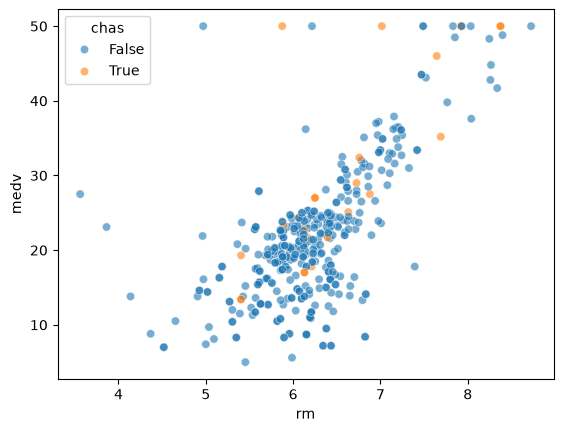

In [10]:
sns.scatterplot(
    data=boston_df.dropna(subset=["chas"]), x="rm", y="medv", hue="chas", alpha=0.6
)


<Axes: xlabel='lstat', ylabel='medv'>

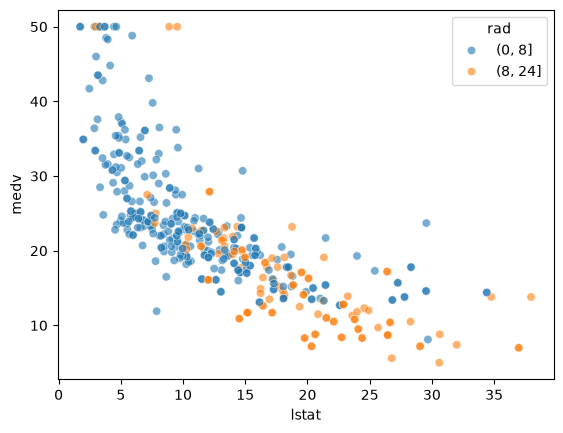

In [12]:
sns.scatterplot(
    data=boston_df.dropna(subset=["lstat", "rad"]),
    x="lstat",
    y="medv",
    hue=pd.cut(boston_df["rad"].dropna(), bins=[0, 8, 24]),
    alpha=0.6,
)

Modelo heurístico baseline — versión final

Se retoma el heurístico calibrado en el análisis univariable (`rm`, `lstat`), y se evalúa si
agregar `chas` mejora el ajuste, dado el hallazgo bivariable de +28% en mediana de precio.

In [13]:
def evaluar_heuristica(df, features):
    d = df.dropna(subset=[*features, "medv"])
    modelo = LinearRegression().fit(d[features], d["medv"])
    pred = modelo.predict(d[features])
    mae = (pred - d["medv"]).abs().mean()
    rmse = ((pred - d["medv"]) ** 2).mean() ** 0.5
    return modelo, mae, rmse


for features in [["rm", "lstat"], ["rm", "lstat", "chas"]]:
    modelo, mae, rmse = evaluar_heuristica(
        boston_df.assign(chas=boston_df["chas"].astype(float)), features
    )
    print(f"{features} -> MAE: {mae:.2f} | RMSE: {rmse:.2f}")

['rm', 'lstat'] -> MAE: 3.89 | RMSE: 5.46
['rm', 'lstat', 'chas'] -> MAE: 3.84 | RMSE: 5.33


### Modelo heurístico — resultado final

| Combinación de variables | MAE | RMSE |
|---|---|---|
| Promedio global (referencia ingenua) | 6.67 | 9.22 |
| `rm` + `lstat` | 3.89 | 5.46 |
| `rm` + `lstat` + `chas` | **3.84** | **5.33** |

Agregar `chas` produce una mejora marginal (~1.3% en MAE) sobre el heurístico de 2 variables.
Visualmente, el scatter de `rm` vs `medv` coloreado por `chas` no muestra una separación clara
entre grupos, consistente con esta mejora pequeña — el efecto de `chas` observado en el
análisis bivariable (+28% en mediana) se diluye una vez que se controla por `rm` y `lstat`,
sugiriendo que buena parte de ese efecto bivariable podría estar explicado indirectamente por
propiedades con más cuartos o menor `lstat` en las zonas que limitan con el río, no por `chas`
en sí misma.

**Conclusión: sí es viable un modelo heurístico simple** como baseline. Con solo 2-3 variables
de las 14 disponibles, se reduce el error en ~42% frente a la predicción ingenua. Este es el
piso mínimo que cualquier modelo de ML del Paso 5 (Modelo Baseline) debe superar para
justificar su complejidad: **MAE de referencia = 3.84**.

## 👷 Data preparation or Feature Engineering

## 📊 Analysis of Results and Conclusions 

Description of the results obtained and if there are conclusions that can be drawn from them.

The analysis of results must be related to the description of the task.

**Note:** An analysis of results does not necessarily lead to conclusions, but to ideas or proposals for future work


## Key Takeaways
- [completar VIF: confirmar/negar redundancia tax-rad formalmente]
- [completar: ¿agregar chas mejora el heurístico o el efecto se diluye al controlar por rm/lstat?]
- Techo de censura en medv=50 sigue limitando la interpretación en el segmento alto.

## Transformaciones sugeridas para Feature Engineering
- Eliminar una de {tax, rad} por redundancia confirmada.
- Log-transform en crim, dis, black (skewness extremo, Paso 3.1).
- Evaluar término no lineal (log o polinómico) para lstat, dado su comportamiento no lineal confirmado.

## Datos adicionales potencialmente útiles
- Año de construcción exacto (age solo da % pre-1940).
- Ubicación geográfica (lat/long) para modelar efectos espaciales no capturados por rad/tax.

## Modelo heurístico final
[fórmula ganadora + MAE/RMSE, comparado contra baseline de promedio global: MAE 6.67]

## 💡 Proposals and Ideas
Features candidatas para el Modelo Baseline (Paso 5): rm, lstat, chas, y una de {tax, rad}.

## 💡 Proposals and Ideas

From the results obtained, what ideas or proposals can be generated to continue with the project


## Resumen consolidado — Preparación de datos para Feature Engineering

### Tipos de variable
- `chas`: booleana (ya aplicada).
- `rad`: categórica ordinal (dtype `Int64`; requiere encoding — one-hot o mantenerse ordinal
  según el modelo elegido).
- Resto de variables numéricas: sin cambio de tipo.

### Duplicados
- 80 filas exactamente duplicadas (90 ignorando `ID`). Deduplicar antes de train/test split.
- `ID` no es único (343 valores en 448 filas) — descartar como columna o regenerar tras dedup.

### Multicolinealidad
- `tax` y `rad` son redundantes (correspondencia 1:1 en rad=24 ↔ tax=666; VIF 9.00 y 7.32,
  los más altos del dataset). Eliminar una — se recomienda conservar `tax`.

### Nulos
- 0.22%–3.57% por columna. Imputación por mediana razonable dado el bajo volumen; evaluar
  KNNImputer si se busca aprovechar la correlación entre variables.

### Transformaciones sugeridas
- Log-transform: `crim`, `dis`, `black` (skewness extremo, ver tabla consolidada univariable).
- `lstat`: relación no lineal confirmada con `medv` (Spearman >> Pearson) — evaluar log o
  término polinómico.
- Escalado necesario dado el rango dispar entre variables (`crim` 0–73 vs `rm` 3–9) para
  modelos sensibles a escala (regresión regularizada, KNN, SVM); no crítico para árboles.

### Variable objetivo (medv)
- Censura en el techo: 14 registros con valor exacto 50.0. Considerar en la evaluación del
  modelo final, especialmente en el segmento de precios altos.

### Ética / decisión pendiente
- `black`: construcción histórica controversial (ver nota en notebook univariable) — decisión
  de incluir/excluir/transformar aún no tomada, debe resolverse explícitamente en Feature
  Engineering.

### Variables candidatas confirmadas para el Modelo Baseline
`rm`, `lstat`, `chas` (mejora marginal), y una de {`tax`, `rad`} — MAE de referencia: 3.84.